# Normality of Correlations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/testing_normality_of_correlations.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-22*

## Learning objectives

- Use Monte Carlo methods to explore the distribution of sample correlations when the true correlation is zero.
- Verify that the standard `r → t` transformation produces a t-distributed statistic for zero population correlation.
- See why that transformation fails for non-zero population correlation, and how the Fisher-Z transform fixes it.


What does the distribution of sample correlations look like? Here, we take a Monte Carlo approach to test the idea that transforming correlations (when the population correlation is zero) to a t-statistic works and we see what happens when the population correlation is *not* zero.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

rng = np.random.default_rng(seed=7)


## Zero true correlation

Pick a small sample size `N`. We will repeatedly draw two independent samples of size `N` from a standard normal, compute Pearson's `r` for each pair, and collect 10,000 such correlations.

In [2]:
N = 10

Loop through 10,000 instances, computing the Pearson correlation between two independent standard-normal samples each time.

In [3]:
r = np.empty((10000,))

for iloop in range(len(r)):
    x = rng.normal(0.0, 1.0, size=N)
    y = rng.normal(0.0, 1.0, size=N)
    r[iloop] = stats.pearsonr(x, y)[0]


Plot the empirical distribution of the 10,000 sample correlations.

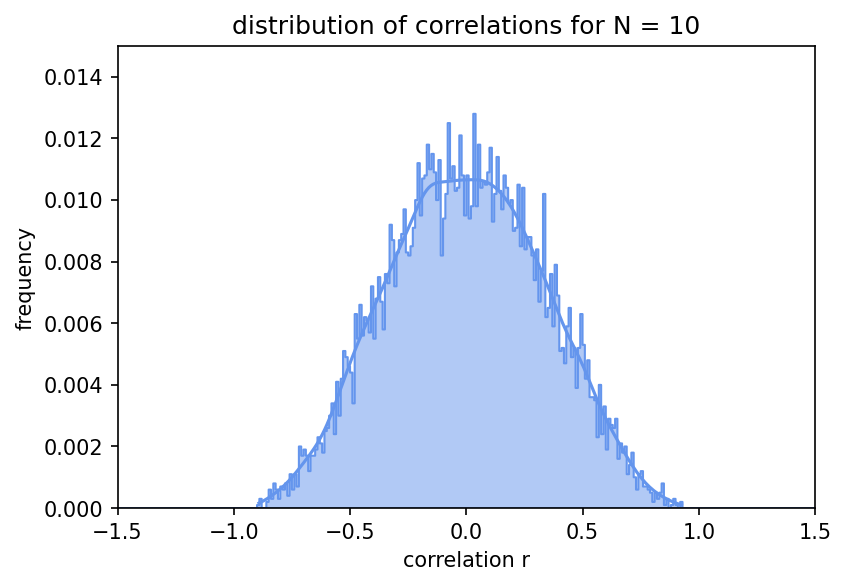

In [4]:
xinc = np.arange(-2.0, 2.0, 0.01)

plt.figure()
sns.histplot(
    r,
    bins=xinc,
    color="cornflowerblue",
    label="correlations",
    kde=True,
    element="step",
    stat="probability",
)
plt.xlim(-1.5, 1.5)
plt.ylim(0, 0.015)
plt.xlabel("correlation r")
plt.ylabel("frequency")
plt.title(f"distribution of correlations for N = {N}")
plt.show()


Correlations can in principle take any value in [-1, 1], but the bulk of these sit within about $\pm 0.5$ — because `x` and `y` are independent, the sample correlations should cluster around zero.

Let's overlay a normal distribution for comparison.

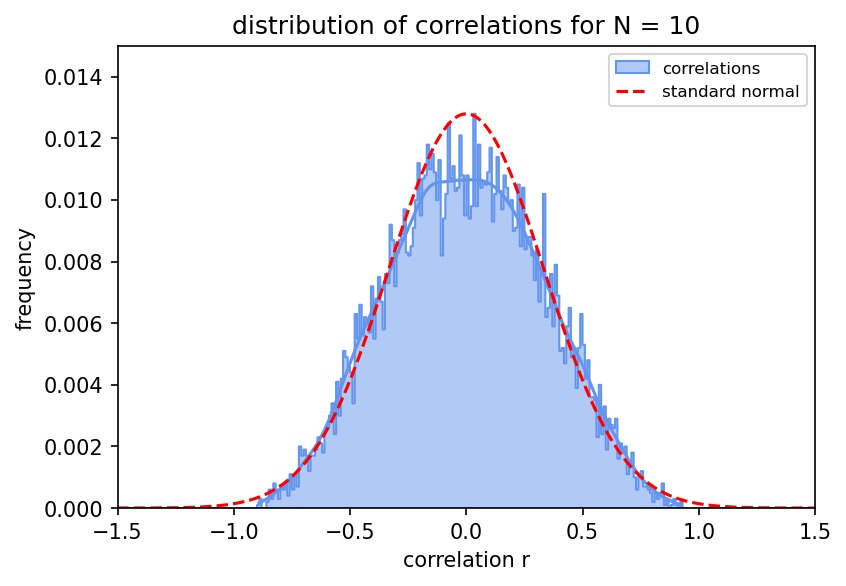

In [5]:
plt.figure()
hx = np.histogram(r, xinc)
plot_hx = hx[0] / float(np.size(r))
sns.histplot(
    r,
    bins=xinc,
    color="cornflowerblue",
    label="correlations",
    kde=True,
    element="step",
    stat="probability",
)
plt.ylim(0, 0.015)
plt.xlabel("correlation r")
plt.ylabel("frequency")
plt.title(f"distribution of correlations for N = {N}")
plt.xlim(-1.5, 1.5)

f = stats.norm.pdf(xinc, loc=0.0, scale=np.std(r))
plt.plot(xinc, (f / np.max(f)) * np.max(plot_hx), "--r", label="standard normal")
plt.legend(fontsize=8)
plt.show()


The fit looks ok — but remember the blue distribution **cannot exceed ±1**, while the red normal can. So a normal is not quite right. We need a transformation that respects the bounds.

## Transform correlations to a t-statistic

Define the standard transformation $t_r = r \sqrt{N - 2}/\sqrt{1 - r^2}$. If our reasoning is right, these `tr` values should follow a t-distribution with $N - 2$ degrees of freedom.

In [6]:
tr = (r * np.sqrt(N - 2)) / (np.sqrt(1 - r**2))


Quick check: what fraction of `tr` values exceed the theoretical 97.5th percentile of the t-distribution? If the transformation is correct, the answer should be ~2.5%.

In [7]:
j = np.where(tr >= stats.t.ppf(0.975, N - 2))
a = np.size(j) / float(np.size(tr))

print("-" * 80)
print(f"N = {N}: t-distribution (theoretical) = 2.5%, Actual (data) = {round(a, 3) * 100.0}%")
print("-" * 80)


--------------------------------------------------------------------------------
N = 10: t-distribution (theoretical) = 2.5%, Actual (data) = 2.6%
--------------------------------------------------------------------------------


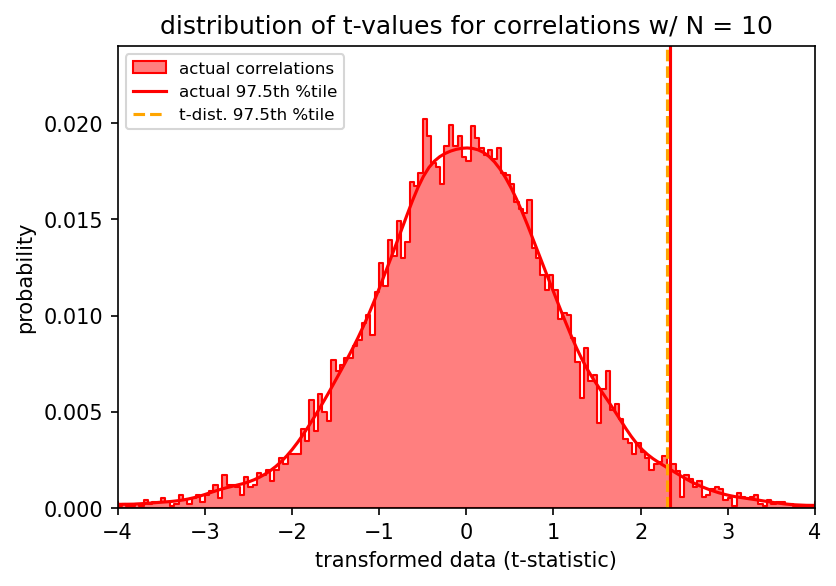

In [8]:
xinc = np.arange(-5.0, 5.0, 0.05)

plt.figure()
sns.histplot(
    tr,
    bins=xinc,
    color="r",
    label="actual correlations",
    kde=True,
    element="step",
    stat="probability",
)
plt.axvline(x=np.percentile(tr, 97.5), color="red", label="actual 97.5th %tile")
plt.axvline(
    x=stats.t.ppf(0.975, N - 2),
    linestyle="--",
    color="orange",
    label="t-dist. 97.5th %tile",
)
plt.xlabel("transformed data (t-statistic)")
plt.ylabel("probability")
plt.xlim(-4, 4)
plt.ylim(0.0, 0.024)
plt.title(f"distribution of t-values for correlations w/ N = {N}")
plt.legend(loc="upper left", fontsize=8)
plt.show()


The transformed correlations match the t-distribution — so we can do statistical tests on them.

We can also use a KS-test to compare the distribution of `tr` values to a standard normal and confirm they differ (because they actually follow a t-distribution).

In [9]:
D, p = stats.kstest(tr, "norm")
print(f"D = {D:.4f}, p = {p:.4g}")


D = 0.0228, p = 6.245e-05


The tiny p-value tells us `tr` is not standard normal — exactly because `tr` follows a t-distribution instead.

## Non-zero true correlation

Now build samples where `x` and `y` *are* correlated: `y = x + 2 * noise`. The population correlation is non-zero. Use a larger sample size `N2 = 20` and collect 100,000 correlations.

In [10]:
N2 = 20
r1 = np.empty((100000,))

for iloop in range(len(r1)):
    x = rng.normal(0.0, 1.0, size=N2)
    y = x + 2.0 * rng.normal(0.0, 1.0, size=N2)
    r1[iloop] = stats.pearsonr(x, y)[0]


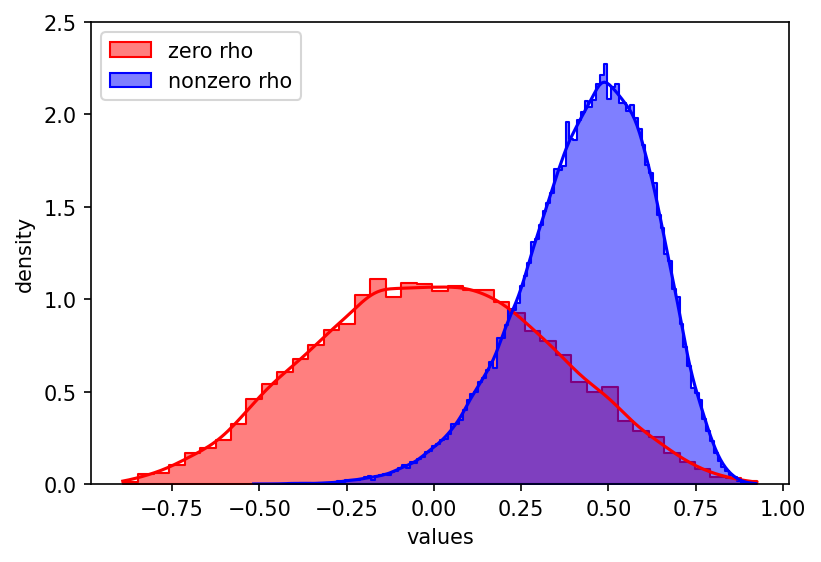

In [11]:
plt.figure()
sns.histplot(r, color="r", label="zero rho", kde=True, element="step", stat="density")
sns.histplot(r1, color="b", label="nonzero rho", kde=True, element="step", stat="density")
plt.ylim(0, 2.5)
plt.xlabel("values")
plt.ylabel("density")
plt.legend()
plt.show()


In [12]:
# Apply the same r → t transformation to the non-zero-correlation data.
tr1 = (r1 * np.sqrt(N - 2)) / (np.sqrt(1 - r1**2))


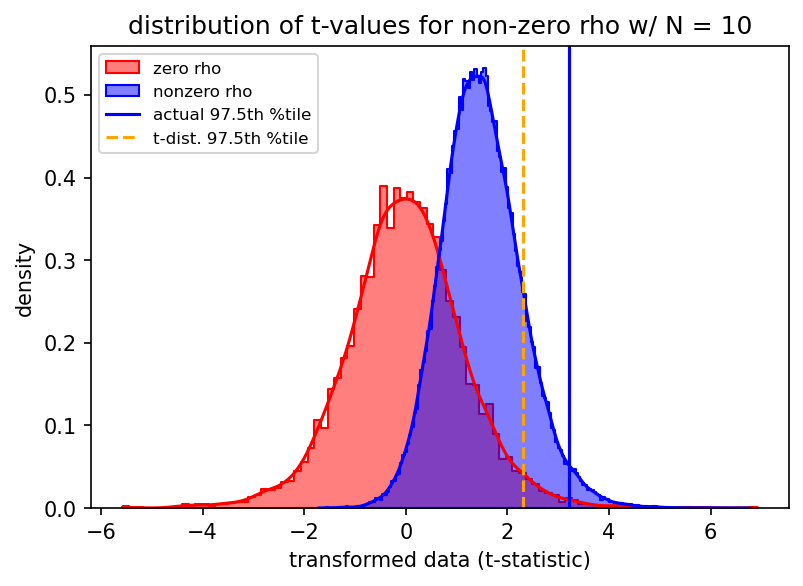

In [13]:
plt.figure()
sns.histplot(tr, color="r", label="zero rho", kde=True, element="step", stat="density")
sns.histplot(tr1, color="b", label="nonzero rho", kde=True, element="step", stat="density")

plt.axvline(x=np.percentile(tr1, 97.5), color="blue", label="actual 97.5th %tile")
plt.axvline(
    x=stats.t.ppf(0.975, N - 2),
    linestyle="--",
    color="orange",
    label="t-dist. 97.5th %tile",
)
plt.xlabel("transformed data (t-statistic)")
plt.ylabel("density")
plt.title(f"distribution of t-values for non-zero rho w/ N = {N}")
plt.legend(loc="upper left", fontsize=8)
plt.show()


The t-distribution does **not** work for the non-zero correlation data. The blue distribution is skewed and shifted — the simple `r → t` transformation only works under the null hypothesis $\rho = 0$. For a non-zero population correlation we need a different transformation.

## Fisher-Z transformation

The Fisher-Z transform $z = \tfrac{1}{2}\ln\frac{1 + r}{1 - r}$ is approximately normal regardless of the population correlation, with $\sigma \approx 1/\sqrt{N - 3}$.

In [14]:
FZ = 0.5 * np.log((1 + r) / (1 - r))
FZ1 = 0.5 * np.log((1 + r1) / (1 - r1))


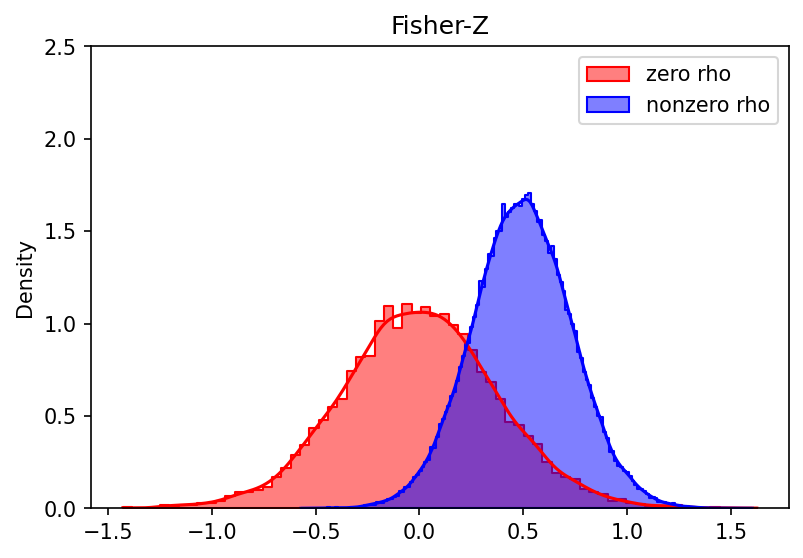

In [15]:
plt.figure()
sns.histplot(FZ, color="r", label="zero rho", kde=True, element="step", stat="density")
sns.histplot(FZ1, color="b", label="nonzero rho", kde=True, element="step", stat="density")
plt.ylim(0, 2.5)
plt.title("Fisher-Z")
plt.legend()
plt.show()


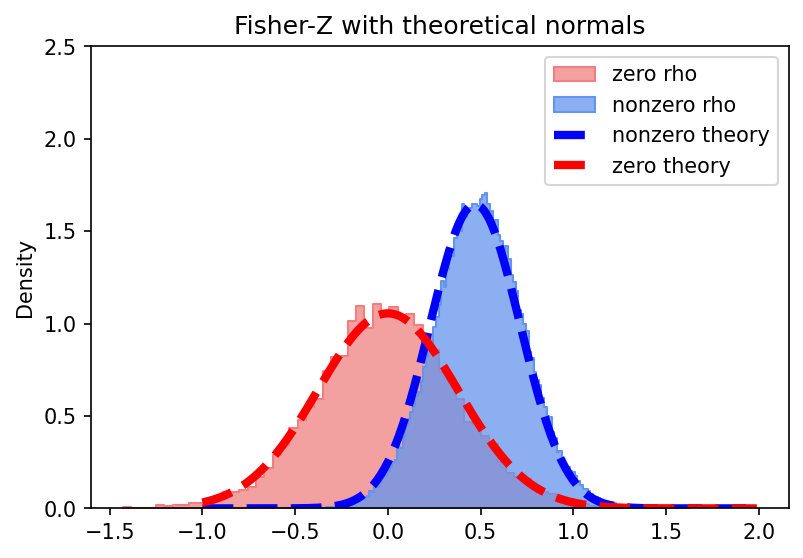

In [16]:
# Theoretical normal for zero rho.
muZ = 0.5 * np.log((1 + np.mean(r)) / (1 - np.mean(r)))
sigmaZ = 1 / np.sqrt(N - 3)
x = np.arange(-1, 2, 0.01)
z_norm0 = stats.norm.pdf(x, loc=muZ, scale=sigmaZ)

# Theoretical normal for nonzero rho.
muZ = 0.5 * np.log((1 + np.mean(r1)) / (1 - np.mean(r1)))
sigmaZ = 1 / np.sqrt(N2 - 3)
x = np.arange(-1, 2, 0.01)
z_norm = stats.norm.pdf(x, loc=muZ, scale=sigmaZ)

plt.figure()
sns.histplot(
    FZ, color="lightcoral", label="zero rho", kde=False, element="step", stat="density"
)
sns.histplot(
    FZ1,
    color="cornflowerblue",
    label="nonzero rho",
    kde=False,
    element="step",
    stat="density",
)
plt.plot(x, z_norm, label="nonzero theory", linestyle="--", color="b", linewidth=4)
plt.plot(x, z_norm0, label="zero theory", linestyle="--", color="r", linewidth=4)
plt.ylim(0, 2.5)
plt.title("Fisher-Z with theoretical normals")
plt.legend()
plt.show()


## Wrap-up

- Under $\rho = 0$, the sample correlation `r` is *not* normal (it's bounded in [-1, 1]), but the transformation $t_r = r\sqrt{N-2}/\sqrt{1-r^2}$ produces a t-distributed statistic that we can test against.
- That transformation only works under the null. For a non-zero population correlation, the distribution of $t_r$ is skewed and shifted.
- The Fisher-Z transform is approximately normal for *any* population correlation, with a known variance — making it the right tool when you want confidence intervals on a non-zero correlation.